---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

In [ ]:
# Instalação das dependências
%pip install numpy matplotlib pandas --quiet

## Aula 01: O que é uma Rede Neural?

Esta aula constrói uma rede neural multicamada **do zero**, sem frameworks, apenas com NumPy. O objetivo é que você entenda cada componente antes de utilizá-los em bibliotecas como PyTorch ou TensorFlow.

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | Contexto histórico e motivação |
| **2** | Matemática de um neurônio artificial |
| **3** | O que caracteriza uma rede neural |
| **4** | Construção completa: pesos, forward, loss, backward, treino |
| **5** | Aplicação real com dados  regressão com normalização |

### Objetivos de aprendizado

Ao final desta aula, você será capaz de:
- Descrever matematicamente o funcionamento de um neurônio
- Implementar forward propagation em uma rede multicamada
- Calcular e interpretar a função de custo
- Entender o papel do backpropagation e do gradiente descendente
- Treinar uma rede para um problema de regressão real

---

## 1. Contexto Histórico

A rede neural artificial é um modelo computacional inspirado no funcionamento do cérebro humano. Sua trajetória até o estado atual foi longa:

| Ano | Marco |
|-----|-------|
| **1943** | McCulloch & Pitts propõem o primeiro modelo matemático de neurônio |
| **1958** | Rosenblatt cria o **Perceptron**  primeiro modelo treinável para tarefas lineares |
| **1969** | Minsky & Papert mostram limitações do Perceptron; pesquisas desaceleram |
| **1986** | Rumelhart & Hinton popularizam o **backpropagation** para redes multicamada |
| **1998** | LeCun desenvolve as primeiras **redes convolucionais** (CNNs) para visão |
| **2012** | AlexNet vence o ImageNet com deep learning em GPU  marco do deep learning moderno |
| **2017** | Vaswani et al. publicam o paper "Attention is All You Need"  origem dos **Transformers** |
| **Hoje** | GPUs massivas, grandes bases de dados e arquiteturas profundas impulsionam LLMs e IA generativa |

### Ideia central

A rede neural artificial é um **aproximador universal de funções**: dado treinamento suficiente, uma rede com camadas suficientes pode aprender a representar qualquer mapeamento $f: \mathbb{R}^n \to \mathbb{R}^m$, por mais complexo que seja.

---

## 2. O Neurônio Artificial

### 2.1 Estrutura matemática

Um neurônio recebe $n$ entradas $x_1, x_2, \ldots, x_n$, cada uma associada a um peso $w_i$, e produz uma saída $a$ em dois passos:

**Passo 1  Combinação linear (potencial interno):**

$$
z = \sum_{i=1}^{n} x_i w_i + b = \mathbf{w}^T \mathbf{x} + b
$$

onde:
- $\mathbf{x} = [x_1, x_2, \ldots, x_n]^T$  vetor de entradas
- $\mathbf{w} = [w_1, w_2, \ldots, w_n]^T$  vetor de pesos (parâmetros treináveis)
- $b$  bias (desloca o limiar de ativação independentemente das entradas)
- $z$  potencial interno (pré-ativação)

**Passo 2  Função de ativação (saída do neurônio):**

$$
a = f(z)
$$

A forma completa de um neurônio é portanto:

$$
\boxed{a = f\!\left(\mathbf{w}^T \mathbf{x} + b\right)}
$$

---

### 2.2 Funções de Ativação

Sem a função de ativação $f(\cdot)$, o neurônio seria puramente linear  e qualquer composição de funções lineares ainda é linear. A **não-linearidade** introduzida por $f$ é o que permite à rede aprender padrões complexos.

| Função | Fórmula | Saída | Uso típico |
|--------|---------|-------|------------|
| **Sigmoide** | $\frac{1}{1+e^{-z}}$ | $(0, 1)$ | Classificação binária (saída) |
| **ReLU** | $\max(0, z)$ | $[0, +\infty)$ | Camadas ocultas (padrão atual) |
| **Tanh** | $\tanh(z)$ | $(-1, 1)$ | Camadas ocultas (centrada em zero) |
| **Softmax** | $\frac{e^{z_k}}{\sum_j e^{z_j}}$ | $(0,1)$, soma $=1$ | Classificação multiclasse (saída) |

> **Por que ReLU é popular?** Além de ser simples e eficiente, ela não sofre do problema de gradiente saturado que afeta sigmoide e tanh para valores extremos de $z$.

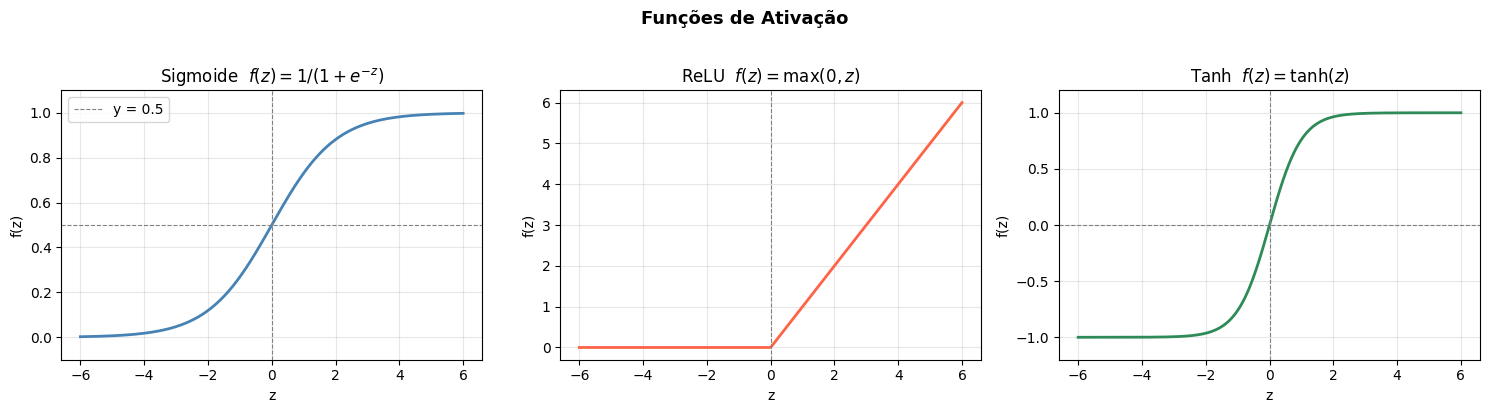

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    # f(z) = 1 / (1 + e^{-z})  →  saída em (0, 1)
    return 1 / (1 + np.exp(-z))

def relu(z):
    # f(z) = max(0, z)  →  saída em [0, +∞)
    return np.maximum(0, z)

def tanh(z):
    # f(z) = tanh(z)  →  saída em (-1, 1)
    return np.tanh(z)

z = np.linspace(-6, 6, 500)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sigmoide
axes[0].plot(z, sigmoid(z), color="steelblue", linewidth=2)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="y = 0.5")
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_title("Sigmoide  $f(z) = 1/(1+e^{-z})$")
axes[0].set_xlabel("z"); axes[0].set_ylabel("f(z)")
axes[0].set_ylim(-0.1, 1.1); axes[0].grid(alpha=0.3); axes[0].legend()

# ReLU
axes[1].plot(z, relu(z), color="tomato", linewidth=2)
axes[1].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("ReLU  $f(z) = \\max(0, z)$")
axes[1].set_xlabel("z"); axes[1].set_ylabel("f(z)")
axes[1].grid(alpha=0.3)

# Tanh
axes[2].plot(z, tanh(z), color="seagreen", linewidth=2)
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_title("Tanh  $f(z) = \\tanh(z)$")
axes[2].set_xlabel("z"); axes[2].set_ylabel("f(z)")
axes[2].set_ylim(-1.2, 1.2); axes[2].grid(alpha=0.3)

plt.suptitle("Funções de Ativação", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 3. Implementando um Neurônio em Python

Agora vamos traduzir a equação $a = f(\mathbf{w}^T\mathbf{x} + b)$ diretamente para código Python, sem NumPy, para deixar cada operação explícita.

**O que a função `neuron` faz:**
1. Calcula a soma ponderada $z = \sum x_i w_i$ com um laço
2. Adiciona o bias: $z \leftarrow z + b$
3. Aplica a sigmoide: $a = \sigma(z)$

In [2]:
def neuron(x, w, b):
    # Passo 1: soma ponderada z = Σ xᵢ·wᵢ
    z = 0.0
    for i in range(len(x)):
        z += x[i] * w[i]

    # Passo 2: adição do bias  z = z + b
    z += b

    # Passo 3: função de ativação  a = σ(z)
    a = sigmoid(z)
    return a


# Exemplo: 2 entradas, pesos e bias definidos manualmente
x = [1.0, 2.0]   # entradas
w = [0.5, -1.0]  # pesos
b = 0.1           # bias

# z = 1.0×0.5 + 2.0×(−1.0) + 0.1 = 0.5 − 2.0 + 0.1 = −1.4
# a = σ(−1.4) ≈ 0.198

saida = neuron(x, w, b)
print(f"z = {sum(xi*wi for xi,wi in zip(x,w)) + b:.4f}")
print(f"a = σ(z) = {saida:.4f}")

z = -1.4000
a = σ(z) = 0.1978


---

## 4. O que Caracteriza uma Rede Neural?

Um único neurônio é um modelo linear (com ativação). A **rede neural** organiza múltiplos neurônios em camadas, criando um modelo capaz de aprender representações hierárquicas dos dados.

Uma rede neural é definida por cinco elementos fundamentais:

| # | Elemento | Descrição | Notação |
|---|----------|-----------|---------|
| 1 | **Neurônios com pesos** | Parâmetros $W$ e $b$ ajustados pelo treinamento | $Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}$ |
| 2 | **Função de ativação** | Introduz não-linearidade entre camadas | $A^{[l]} = f(Z^{[l]})$ |
| 3 | **Arquitetura em camadas** | Entrada → Oculta(s) → Saída | $L$ camadas no total |
| 4 | **Função de custo** | Mede o erro entre predição e alvo | $\mathcal{J}(W, b)$ |
| 5 | **Backpropagation** | Calcula gradientes via regra da cadeia | $\nabla_{W}\mathcal{J},\; \nabla_{b}\mathcal{J}$ |

### Arquitetura típica

<div align="center">
  <img src="imgs/img01.png" width="500" alt="descrição">
</div>

A profundidade (número de camadas) e a largura (neurônios por camada) são **hiperparâmetros** escolhidos pelo projetista da rede.

---

## 5. Construção de uma Rede Neural do Zero

Vamos implementar cada componente separadamente para entender o papel de cada um:

```
5.1  WeightStarter       →  inicializa W e b para cada camada
5.2  Funções de ativação →  sigmoid, relu, tanh
5.3  ForwardPropagation  →  calcula ŷ passando por todas as camadas
5.4  compute_cost        →  mede o erro (loss)
5.5  BackPropagation     →  calcula os gradientes dW e db
5.6  Loop de treinamento →  repete forward → loss → backward → update
```

### 5.1 Inicialização dos Pesos (`WeightStarter`)

Antes de treinar, precisamos definir valores iniciais para $W^{[l]}$ e $b^{[l]}$ em cada camada $l$.

**Formato das matrizes:**

Para uma camada $l$ com $n^{[l]}$ neurônios recebendo $n^{[l-1]}$ entradas:

$$
W^{[l]} \in \mathbb{R}^{n^{[l]} \times n^{[l-1]}}, \qquad b^{[l]} \in \mathbb{R}^{n^{[l]} \times 1}
$$

**Por que pequenos valores aleatórios para $W$?**
- **Aleatório:** quebra a simetria  se todos os pesos fossem iguais, todos os neurônios aprenderiam a mesma coisa.
- **Pequeno (×0.01):** evita que a ativação sigmoide/tanh inicie na região saturada, onde o gradiente é quase zero.

**Por que $b = 0$?**  
O bias não sofre do problema de simetria, então inicializar em zero é suficiente.

**Exemplo de arquitetura `[2, 4, 3, 1]`:**
```
Camada de entrada:  2 neurônios  (features)
Camada oculta 1:    4 neurônios  →  W¹ ∈ ℝ^(4×2),  b¹ ∈ ℝ^(4×1)
Camada oculta 2:    3 neurônios  →  W² ∈ ℝ^(3×4),  b² ∈ ℝ^(3×1)
Camada de saída:    1 neurônio   →  W³ ∈ ℝ^(1×3),  b³ ∈ ℝ^(1×1)
```

In [3]:
# dim_input_layer: lista com o nº de neurônios em cada camada (entrada + ocultas + saída)
# Exemplo: [2, 4, 3, 1]
#   Camada 0 (entrada):   2 features
#   Camada 1 (oculta 1):  4 neurônios  →  W¹ shape (4, 2)
#   Camada 2 (oculta 2):  3 neurônios  →  W² shape (3, 4)
#   Camada 3 (saída):     1 neurônio   →  W³ shape (1, 3)

def WeightStarter(dim_input_layer, value=0.01):
    parameters = {}
    num_layers = len(dim_input_layer)

    for l in range(1, num_layers):
        # W[l]: shape (n[l], n[l-1])  pequenos valores aleatórios
        parameters["W" + str(l)] = np.random.randn(
            dim_input_layer[l], dim_input_layer[l - 1]
        ) * value

        # b[l]: shape (n[l], 1)  zeros
        parameters["b" + str(l)] = np.zeros((dim_input_layer[l], 1))

    return parameters

# Inspecionando os shapes para arquitetura [2, 4, 3, 1]
params_exemplo = WeightStarter([2, 4, 3, 1])
for key, val in params_exemplo.items():
    print(f"  {key}: shape {val.shape}")

  W1: shape (4, 2)
  b1: shape (4, 1)
  W2: shape (3, 4)
  b2: shape (3, 1)
  W3: shape (1, 3)
  b3: shape (1, 1)


In [4]:
params_exemplo

{'W1': array([[-0.02135863, -0.01590023],
        [ 0.00340242, -0.00281134],
        [-0.00761589, -0.00878982],
        [-0.01454702, -0.00124922]]),
 'b1': array([[0.],
        [0.],
        [0.],
        [0.]]),
 'W2': array([[ 0.01074304, -0.01527168, -0.00466523,  0.00457882],
        [ 0.00553639,  0.02380163, -0.00070705,  0.00590578],
        [ 0.00358956,  0.00577506, -0.03590802, -0.00782762]]),
 'b2': array([[0.],
        [0.],
        [0.]]),
 'W3': array([[-0.00184939,  0.01751471, -0.00732578]]),
 'b3': array([[0.]])}

### 5.2 Funções de Ativação

As mesmas funções já definidas na seção 2  redefinidas aqui para que o notebook seja auto-contido.

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

### 5.3 Forward Propagation

A forward propagation propaga os dados de entrada camada por camada até produzir a predição $\hat{y} = A^{[L]}$.

Para cada camada $l = 1, 2, \ldots, L$:

$$
Z^{[l]} = W^{[l]} A^{[l-1]} + b^{[l]}
$$
$$
A^{[l]} = f^{[l]}(Z^{[l]})
$$

onde $A^{[0]} = X$ (a entrada) e:
- Camadas ocultas usam **ReLU**: $f(z) = \max(0, z)$
- Camada de saída usa **Sigmoide** (para classificação binária): $f(z) = \sigma(z)$

O dicionário `caches` guarda $Z^{[l]}$ e $A^{[l]}$ de cada camada  eles serão necessários na backward propagation.

In [6]:
def ForwardPropagation(X, parameters):
    caches = {}
    A = X
    caches["A0"] = X                    # A[0] = X (entrada)

    L = len(parameters) // 2           # número total de camadas com pesos

    # Camadas ocultas l = 1, ..., L-1  →  ativação ReLU
    for l in range(1, L):
        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]

        Z = np.dot(W, A) + b            # Z[l] = W[l] · A[l-1] + b[l]
        A = relu(Z)                     # A[l] = relu(Z[l])

        caches["Z" + str(l)] = Z
        caches["A" + str(l)] = A

    # Camada de saída l = L  →  ativação Sigmoide (classificação binária)
    W = parameters["W" + str(L)]
    b = parameters["b" + str(L)]

    ZL = np.dot(W, A) + b              # Z[L] = W[L] · A[L-1] + b[L]
    AL = sigmoid(ZL)                   # A[L] = σ(Z[L])  ∈ (0, 1)

    caches["Z" + str(L)] = ZL
    caches["A" + str(L)] = AL

    return AL, caches

# Teste: 5 exemplos com 2 features
params = WeightStarter([2, 4, 3, 1])
X_test = np.random.randn(2, 5)

AL, caches = ForwardPropagation(X_test, params)
print("Shape AL:", AL.shape)           # (1, 5)  uma predição por exemplo
print("AL (predições):\n", AL.round(4))

Shape AL: (1, 5)
AL (predições):
 [[0.5 0.5 0.5 0.5 0.5]]


### 5.4 Função de Custo  Binary Cross-Entropy

Para classificação binária, usamos a **entropia cruzada binária** (log-loss):

$$
\mathcal{J}(W, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\!\left(\hat{y}^{(i)}\right) + \left(1 - y^{(i)}\right) \log\!\left(1 - \hat{y}^{(i)}\right) \right]
$$

onde:
- $m$  número de exemplos de treinamento
- $y^{(i)} \in \{0, 1\}$  rótulo real do exemplo $i$
- $\hat{y}^{(i)} = A^{[L](i)}$  probabilidade predita pela rede

**Intuição:** quando $y=1$ e $\hat{y} \approx 1$, o custo é próximo de zero. Quando $y=1$ e $\hat{y} \approx 0$, o custo dispara ($-\log(0) \to \infty$). A função penaliza erros de confiança de forma assimétrica e diferenciável.

In [7]:
def compute_cost(AL, Y):
    m = Y.shape[1]  # número de exemplos

    # J = -(1/m) · Σ [ y·log(ŷ) + (1-y)·log(1-ŷ) ]
    cost = (-1 / m) * np.sum(
        Y * np.log(AL) + (1 - Y) * np.log(1 - AL)
    )

    return np.squeeze(cost)  # garante escalar (não array 1D)

# Exemplo: 3 predições e rótulos reais
AL = np.array([[0.8, 0.3, 0.9]])   # predições da rede
Y  = np.array([[1,   0,   1  ]])   # rótulos reais

cost = compute_cost(AL, Y)
print(f"Custo (cross-entropy): {cost:.4f}")

Custo (cross-entropy): 0.2284


### 5.5 Backpropagation

O backpropagation aplica a **regra da cadeia** para propagar o erro da camada de saída de volta até a camada de entrada, calculando como cada peso contribuiu para o custo.

**Camada de saída $L$ (Sigmoide + Cross-Entropy):**

A derivada combinada sigmoide + cross-entropy simplifica elegantemente para:

$$
dZ^{[L]} = A^{[L]} - Y
$$

A partir de $dZ^{[L]}$, os gradientes da camada $L$ são:

$$
dW^{[L]} = \frac{1}{m} \, dZ^{[L]} \cdot A^{[L-1]T}
\qquad
db^{[L]} = \frac{1}{m} \sum dZ^{[L]}
\qquad
dA^{[L-1]} = W^{[L]T} \cdot dZ^{[L]}
$$

**Camadas ocultas $l = L-1, \ldots, 1$ (ReLU):**

A derivada da ReLU é:

$$
f'(z) = \begin{cases} 1 & \text{se } z > 0 \\ 0 & \text{se } z \leq 0 \end{cases}
$$

Portanto:
$$
dZ^{[l]} = dA^{[l]} \odot \mathbf{1}[Z^{[l]} > 0]
$$

onde $\odot$ é o produto elemento a elemento e $\mathbf{1}[\cdot]$ é a função indicadora.

> **Regra da cadeia:** o backpropagation é simplesmente a regra da cadeia aplicada sistematicamente da saída para a entrada. Cada $dA^{[l-1]}$ é o "erro" que chega à camada $l-1$, e serve de entrada para o cálculo de $dZ^{[l-1]}$ na próxima iteração do laço.

In [8]:
def BackPropagation(X, Y, parameters, caches):
    grads = {}
    m = X.shape[1]
    L = len(parameters) // 2

    AL = caches["A" + str(L)]

    # ── Camada de saída L (Sigmoide + Cross-Entropy) ──────────────────────
    # dZ[L] = A[L] - Y  (derivada combinada sigmoide + cross-entropy)
    dZL = AL - Y

    grads["dW" + str(L)] = (1/m) * np.dot(dZL, caches["A" + str(L-1)].T)
    grads["db" + str(L)] = (1/m) * np.sum(dZL, axis=1, keepdims=True)
    grads["dA" + str(L-1)] = np.dot(parameters["W" + str(L)].T, dZL)

    # ── Camadas ocultas l = L-1, ..., 1 (ReLU) ───────────────────────────
    for l in reversed(range(1, L)):
        # Derivada da ReLU: f'(z) = 1 se z > 0, senão 0
        dZ = grads["dA" + str(l)].copy()
        dZ[caches["Z" + str(l)] <= 0] = 0   # zera onde Z ≤ 0

        grads["dW" + str(l)] = (1/m) * np.dot(dZ, caches["A" + str(l-1)].T)
        grads["db" + str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            grads["dA" + str(l-1)] = np.dot(parameters["W" + str(l)].T, dZ)

    return grads

### 5.6 Demonstração Passo a Passo

Antes do loop completo, vamos executar cada etapa individualmente para entender o fluxo de dados.

In [9]:
import numpy as np

# Dados sintéticos para demonstração: 5 exemplos, 2 features
params = WeightStarter([2, 4, 3, 1])
X = np.random.randn(2, 5)
Y = np.array([[1, 0, 1, 0, 1]])

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (2, 5)
Y shape: (1, 5)


In [10]:
X

array([[ 0.30443686,  0.30689595,  0.49213959,  0.47373076,  0.01606724],
       [ 0.05520383,  0.61442028, -1.97407023,  0.42019854,  0.02295071]])

**Passo 1  Forward:** propaga $X$ pela rede e obtém $\hat{y} = A^{[L]}$

In [11]:
AL, caches = ForwardPropagation(X, params)
AL

array([[0.49999994, 0.49999984, 0.49999939, 0.4999999 , 0.49999999]])

In [12]:
caches

{'A0': array([[ 0.30443686,  0.30689595,  0.49213959,  0.47373076,  0.01606724],
        [ 0.05520383,  0.61442028, -1.97407023,  0.42019854,  0.02295071]]),
 'Z1': array([[-4.21916570e-03, -6.79472192e-03,  2.56410577e-03,
         -8.08588866e-03, -3.13810647e-04],
        [ 3.19095191e-03,  8.12143823e-03, -1.29527314e-02,
          7.89975321e-03,  3.44289094e-04],
        [-3.79480501e-03, -8.87946069e-03,  1.25278415e-02,
         -8.92871920e-03, -3.81512133e-04],
        [-9.30428523e-05,  1.27684370e-02, -4.76453536e-02,
          7.55032343e-03,  4.56322525e-04]]),
 'A1': array([[0.        , 0.        , 0.00256411, 0.        , 0.        ],
        [0.00319095, 0.00812144, 0.        , 0.00789975, 0.00034429],
        [0.        , 0.        , 0.01252784, 0.        , 0.        ],
        [0.        , 0.01276844, 0.        , 0.00755032, 0.00045632]]),
 'Z2': array([[ 1.90469402e-05, -7.83748871e-05,  2.16402614e-04,
         -2.78571135e-05, -2.47840474e-06],
        [-2.22444053

**Passo 2  Loss:** calcula o custo $\mathcal{J}$ entre $A^{[L]}$ e $Y$

In [13]:
cost = compute_cost(AL, Y)
cost

np.float64(0.6931473493879954)

**Passo 3  Backward:** calcula os gradientes $dW^{[l]}$ e $db^{[l]}$

In [14]:
grads = BackPropagation(X, Y, params, caches)
grads

{'dW3': array([[-2.35449820e-05,  0.00000000e+00,  2.40934772e-05]]),
 'db3': array([[-0.10000019]]),
 'dA2': array([[ 0.00563149, -0.00563149,  0.0056315 , -0.00563149,  0.00563149],
        [-0.00123623,  0.00123623, -0.00123623,  0.00123623, -0.00123623],
        [ 0.00199968, -0.00199968,  0.00199968, -0.00199968,  0.00199968]]),
 'dW2': array([[ 2.88795211e-06,  3.59396490e-06,  1.41101068e-05,
          0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00],
        [ 0.00000000e+00, -4.99358376e-06,  0.00000000e+00,
         -7.94370891e-06]]),
 'db2': array([[2.25259859e-03],
        [0.00000000e+00],
        [2.54720902e-10]]),
 'dA1': array([[ 3.27577236e-05,  5.08328813e-06,  3.78410555e-05,
          5.08328871e-06, -5.08328976e-06],
        [ 3.75720424e-05, -3.95739504e-06,  3.36146826e-05,
         -3.95739550e-06,  3.95739632e-06],
        [ 6.47755940e-05,  2.47563010e-05,  8.95320040e-05,
          2.47563038e-05, -2.475

**Passo 4  Atualização:** aplica o gradiente descendente com $\eta = 0.5$

$$W^{[l]} \leftarrow W^{[l]} - \eta \cdot dW^{[l]}, \qquad b^{[l]} \leftarrow b^{[l]} - \eta \cdot db^{[l]}$$

In [15]:
learning_rate = 0.5

for l in range(1, len(params) // 2 + 1):
    params["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
    params["b" + str(l)] -= learning_rate * grads["db" + str(l)]

print("Atualização concluída. Executando novo forward para verificar redução do custo...")
AL_novo, _ = ForwardPropagation(X, params)
print(f"  Custo antes: {compute_cost(AL, Y):.4f}")
print(f"  Custo após:  {compute_cost(AL_novo, Y):.4f}")

Atualização concluída. Executando novo forward para verificar redução do custo...
  Custo antes: 0.6931
  Custo após:  0.6885


### 5.7 Loop Completo de Treinamento

Os 4 passos acima são repetidos por `epochs` iterações. A cada iteração, o custo deve diminuir  isso indica que o gradiente está guiando os pesos na direção correta.

In [16]:
params = WeightStarter([2, 4, 3, 1])
lr = 0.5
epochs = 3000

for i in range(epochs):
    # Forward → Loss → Backward → Update
    AL, caches = ForwardPropagation(X, params)
    cost       = compute_cost(AL, Y)
    grads      = BackPropagation(X, Y, params, caches)

    for l in range(1, len(params) // 2 + 1):
        params["W" + str(l)] -= lr * grads["dW" + str(l)]
        params["b" + str(l)] -= lr * grads["db" + str(l)]

    if i % 500 == 0:
        print(f"Epoch {i:>4} | Custo: {cost:.6f}")

Epoch    0 | Custo: 0.693147
Epoch  500 | Custo: 0.672560
Epoch 1000 | Custo: 0.005591
Epoch 1500 | Custo: 0.002451
Epoch 2000 | Custo: 0.001561
Epoch 2500 | Custo: 0.001144


---

## 6. Aplicação com Dados Reais  Regressão

Agora aplicamos a rede a um dataset real de **regressão**: a tarefa é prever um valor contínuo (não uma probabilidade).

**Diferença em relação à classificação:**

| Aspecto | Classificação binária | Regressão |
|---|---|---|
| Ativação da saída | Sigmoide ($\in (0,1)$) | Linear (sem ativação) |
| Função de custo | Binary Cross-Entropy | MSE: $\frac{1}{m}\sum(\hat{y}_i - y_i)^2$ |
| Derivada na saída | $dZ^{[L]} = A^{[L]} - Y$ (igual!) | $dZ^{[L]} = A^{[L]} - Y$ |

> Curiosidade: a derivada do gradiente na camada de saída tem a mesma forma em ambos os casos  o que muda é a interpretação da saída e a escala do erro.

In [17]:
import pandas as pd

# Dataset com 4 features numéricas e 1 alvo contínuo
df = pd.read_csv("data/regression_example.csv")
print("Shape:", df.shape)
print("\nEstatísticas descritivas:")
df.describe()

Shape: (400, 5)

Estatísticas descritivas:


,feature1,feature2,feature3,feature4,target
count,400.000000,400.000000,400.000000,400.000000,400.000000
mean,5.197429,5.024359,4.902299,5.016093,23.335552
std,2.882820,2.740042,2.800285,2.947727,13.370127
min,0.028356,0.034733,0.016913,0.061058,-9.328168
25%,2.600131,2.688347,2.550522,2.568386,13.824976
50%,5.307046,5.253612,4.889624,4.932685,22.713519
75%,7.672316,7.183742,7.256450,7.702533,32.522920
max,9.999078,9.945254,9.992825,9.989023,57.383132


### 6.1 Versão sem normalização (baseline)

Redefinimos `ForwardPropagation` e `BackPropagation` para **regressão** (saída linear, custo MSE), e treinamos diretamente nos dados brutos.

In [18]:
def ForwardPropagation(X, parameters):
    """Forward propagation para regressão: camadas ocultas com ReLU, saída linear."""
    caches = {}
    A = X
    caches["A0"] = X

    L = len(parameters) // 2

    # Camadas ocultas: ReLU
    for l in range(1, L):
        W = parameters["W" + str(l)]
        b = parameters["b" + str(l)]
        Z = np.dot(W, A) + b
        A = relu(Z)
        caches["Z" + str(l)] = Z
        caches["A" + str(l)] = A

    # Camada de saída: LINEAR (sem ativação → valor contínuo)
    W = parameters["W" + str(L)]
    b = parameters["b" + str(L)]
    ZL = np.dot(W, A) + b
    AL = ZL                             # saída linear: ŷ ∈ ℝ

    caches["Z" + str(L)] = ZL
    caches["A" + str(L)] = AL

    return AL, caches

def compute_cost(AL, Y):
    """MSE: (1/m) · Σ(ŷᵢ - yᵢ)²"""
    m = Y.shape[1]
    cost = (1 / m) * np.sum((AL - Y) ** 2)
    return cost

def BackPropagation(X, Y, parameters, caches):
    """Backpropagation para regressão (MSE + saída linear)."""
    grads = {}
    m = X.shape[1]
    L = len(parameters) // 2

    AL = caches["A" + str(L)]

    # ── Camada de saída (Linear + MSE): dZ[L] = AL - Y ───────────────────
    dZ = AL - Y

    grads["dW" + str(L)] = (1/m) * np.dot(dZ, caches["A" + str(L-1)].T)
    grads["db" + str(L)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    grads["dA" + str(L-1)] = np.dot(parameters["W" + str(L)].T, dZ)

    # ── Camadas ocultas (ReLU) ────────────────────────────────────────────
    for l in reversed(range(1, L)):
        dZ = grads["dA" + str(l)].copy()
        dZ[caches["Z" + str(l)] <= 0] = 0   # derivada da ReLU

        grads["dW" + str(l)] = (1/m) * np.dot(dZ, caches["A" + str(l-1)].T)
        grads["db" + str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            grads["dA" + str(l-1)] = np.dot(parameters["W" + str(l)].T, dZ)

    return grads

In [19]:
# Features como matriz (n_features × m_exemplos)  convenção de álgebra linear
X = df[["feature1", "feature2", "feature3", "feature4"]].values.T  # (4, m)
Y = df["target"].values.reshape(1, -1)                              # (1, m)

print("X shape:", X.shape)   # (4, m)  4 features
print("Y shape:", Y.shape)   # (1, m)  1 alvo

X shape: (4, 400)
Y shape: (1, 400)


**Arquitetura escolhida:** `[4, 10, 5, 1]`
- 4 entradas (features)
- 10 neurônios na 1ª camada oculta
- 5 neurônios na 2ª camada oculta
- 1 saída contínua

In [20]:
params = WeightStarter([4, 10, 5, 1])
for k, v in params.items():
    print(f"  {k}: shape {v.shape}")

  W1: shape (10, 4)
  b1: shape (10, 1)
  W2: shape (5, 10)
  b2: shape (5, 1)
  W3: shape (1, 5)
  b3: shape (1, 1)


**Treinamento sem normalização**  `lr=0.05`, `5000 épocas`

In [21]:
learning_rate = 0.05
epochs = 5000

cost_history = []

for i in range(epochs):
    AL, caches = ForwardPropagation(X, params)
    cost       = compute_cost(AL, Y)
    grads      = BackPropagation(X, Y, params, caches)

    for l in range(1, len(params) // 2 + 1):
        params["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        params["b" + str(l)] -= learning_rate * grads["db" + str(l)]

    cost_history.append(cost)

    if i % 1000 == 0:
        print(f"Epoch {i:>5} | MSE: {cost:.4f}")

Epoch     0 | MSE: 722.8608
Epoch  1000 | MSE: 178.3134
Epoch  2000 | MSE: 178.3134
Epoch  3000 | MSE: 178.3134
Epoch  4000 | MSE: 178.3134


RMSE sem normalização: 13.3534


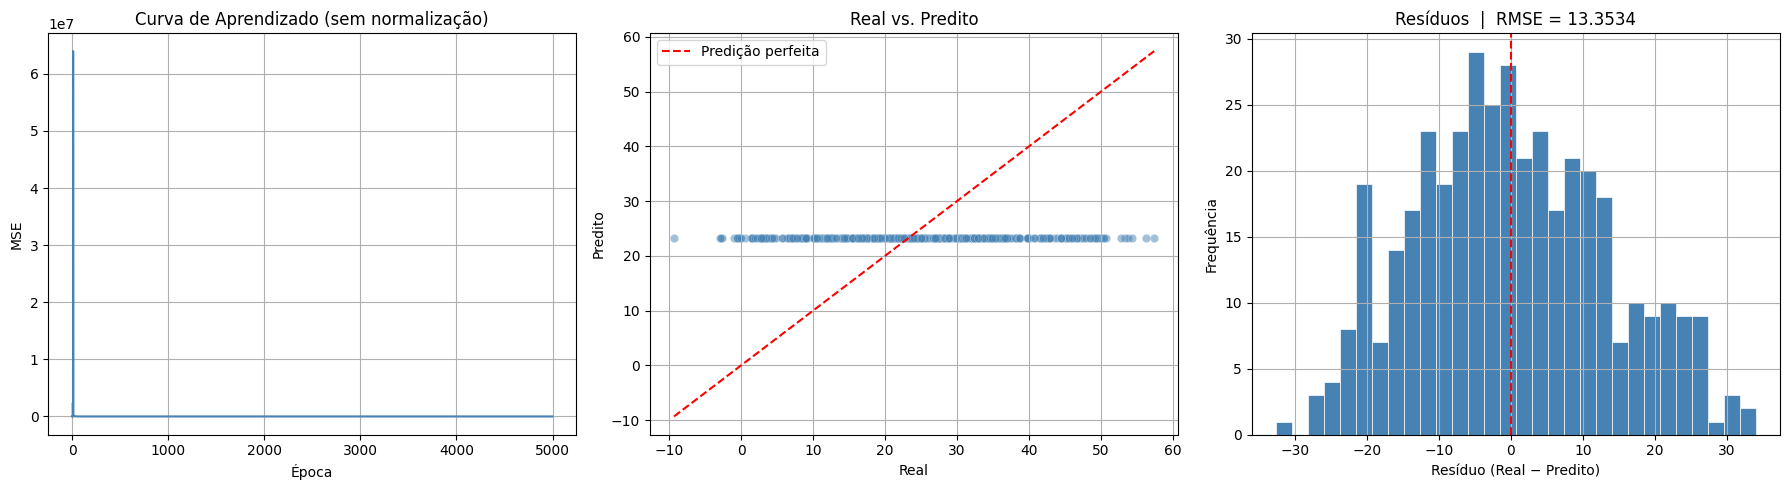

In [22]:
AL_pred, _ = ForwardPropagation(X, params)
rmse_before = np.sqrt(np.mean((AL_pred - Y) ** 2))
print(f"RMSE sem normalização: {rmse_before:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de aprendizado
axes[0].plot(cost_history, color="steelblue", linewidth=1.5)
axes[0].set_title("Curva de Aprendizado (sem normalização)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("MSE"); axes[0].grid(True)

# 2. Real vs. Predito
y_real = Y.flatten()
y_pred = AL_pred.flatten()
axes[1].scatter(y_real, y_pred, alpha=0.5, color="steelblue", edgecolors="white", linewidths=0.3)
lim = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
axes[1].plot(lim, lim, "r--", linewidth=1.5, label="Predição perfeita")
axes[1].set_title("Real vs. Predito"); axes[1].set_xlabel("Real"); axes[1].set_ylabel("Predito")
axes[1].legend(); axes[1].grid(True)

# 3. Distribuição dos resíduos
residuos = y_real - y_pred
axes[2].hist(residuos, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[2].set_title(f"Resíduos  |  RMSE = {rmse_before:.4f}")
axes[2].set_xlabel("Resíduo (Real − Predito)"); axes[2].set_ylabel("Frequência"); axes[2].grid(True)

plt.tight_layout()
plt.show()

### 6.2 Por que normalizar os dados?

Quando as features têm escalas muito diferentes, o gradiente descendente enfrenta um **terreno de custo desequilibrado**: passos que são bons para uma feature causam oscilação em outra.

**Normalização Z-score (padronização):**

$$
X_{\text{norm}} = \frac{X - \mu}{\sigma + \varepsilon}
$$

onde $\mu$ é a média e $\sigma$ o desvio padrão calculados **no conjunto de treino** (nunca no teste). O termo $\varepsilon = 10^{-8}$ evita divisão por zero.

**Efeitos esperados após normalizar:**
- Todas as features ficam na mesma escala → gradientes mais equilibrados
- A rede converge mais rápido e com learning rate maior
- Menor risco de gradientes explodindo ou sumindo

> **Regra prática:** sempre normalize os inputs. Depois de treinar, aplique a transformação inversa para interpretar as predições na escala original.

X  média após normalização: [0. 0. 0. 0.]
X  std  após normalização: [1. 1. 1. 1.]
Y  média após normalização: 0.0
Y  std  após normalização: 1.0
Epoch     0  |  Custo (MSE normalizado): 0.999997
Epoch   500  |  Custo (MSE normalizado): 0.999424
Epoch  1000  |  Custo (MSE normalizado): 0.039731
Epoch  1500  |  Custo (MSE normalizado): 0.026449
Epoch  2000  |  Custo (MSE normalizado): 0.024287
Epoch  2500  |  Custo (MSE normalizado): 0.023753
Epoch  3000  |  Custo (MSE normalizado): 0.023377
Epoch  3500  |  Custo (MSE normalizado): 0.023129
Epoch  4000  |  Custo (MSE normalizado): 0.022899
Epoch  4500  |  Custo (MSE normalizado): 0.022706
Epoch  5000  |  Custo (MSE normalizado): 0.022579
Epoch  5500  |  Custo (MSE normalizado): 0.022481
Epoch  6000  |  Custo (MSE normalizado): 0.022390
Epoch  6500  |  Custo (MSE normalizado): 0.022298
Epoch  7000  |  Custo (MSE normalizado): 0.022232
Epoch  7500  |  Custo (MSE normalizado): 0.022171
Epoch  8000  |  Custo (MSE normalizado): 0.022107
Epoc

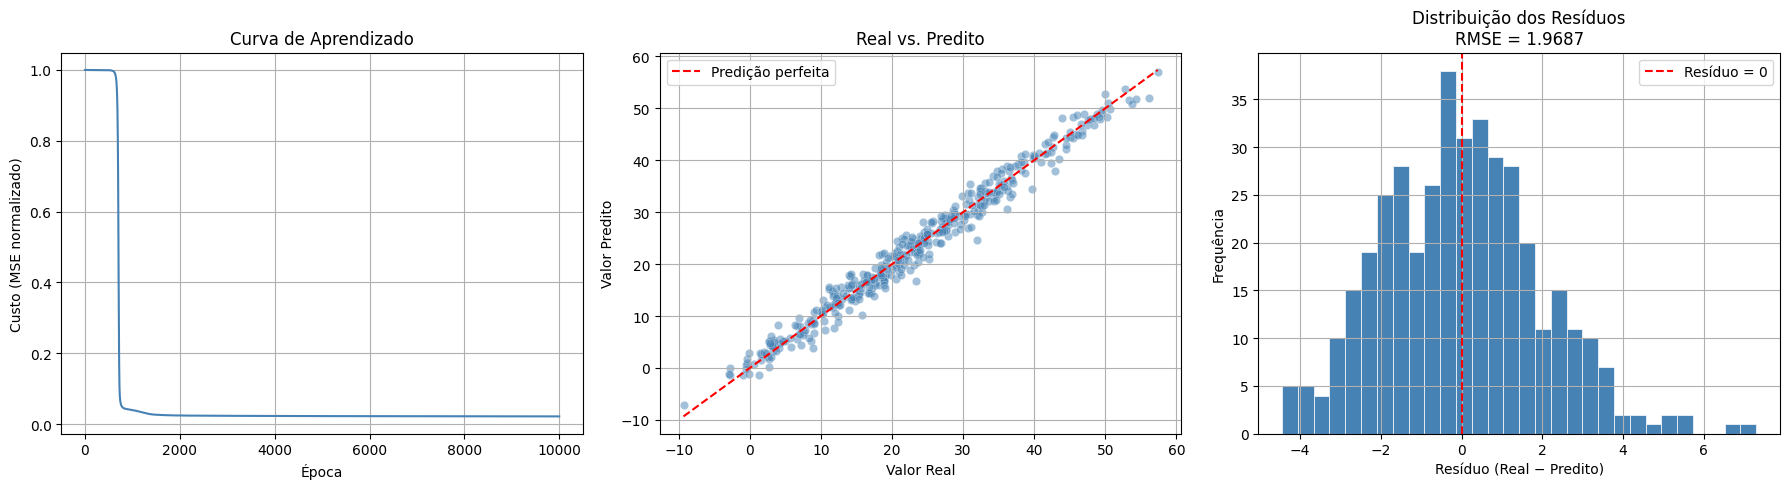

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# Normalização manual (Z-score / Padronização)
# ─────────────────────────────────────────

def normalize_fit(X):
    media = np.mean(X, axis=1, keepdims=True)
    desvio = np.std(X, axis=1, keepdims=True)
    return media, desvio

def normalize_transform(X, media, desvio):
    return (X - media) / (desvio + 1e-8)

def normalize_inverse(X_norm, media, desvio):
    return X_norm * (desvio + 1e-8) + media

# ─────────────────────────────────────────
# Carregamento e preparação dos dados
# ─────────────────────────────────────────

df = pd.read_csv("data/regression_example.csv")

X_raw = df[["feature1", "feature2", "feature3", "feature4"]].values.T
Y_raw = df["target"].values.reshape(1, -1)

media_X, desvio_X = normalize_fit(X_raw)
media_Y, desvio_Y = normalize_fit(Y_raw)

X = normalize_transform(X_raw, media_X, desvio_X)
Y = normalize_transform(Y_raw, media_Y, desvio_Y)

print("X  média após normalização:", np.mean(X, axis=1).round(4))
print("X  std  após normalização:", np.std(X,  axis=1).round(4))
print("Y  média após normalização:", np.mean(Y).round(4))
print("Y  std  após normalização:", np.std(Y).round(4))

# ─────────────────────────────────────────
# Treinamento
# ─────────────────────────────────────────

params = WeightStarter([4, 20, 10, 1])
learning_rate = 0.1
epochs = 10000
historico_custo = []

for i in range(epochs):
    AL, caches = ForwardPropagation(X, params)
    cost       = compute_cost(AL, Y)
    grads      = BackPropagation(X, Y, params, caches)

    historico_custo.append(cost)

    for l in range(1, len(params) // 2 + 1):
        params["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        params["b" + str(l)] -= learning_rate * grads["db" + str(l)]

    if i % 500 == 0:
        print(f"Epoch {i:>5}  |  Custo (MSE normalizado): {cost:.6f}")

# ─────────────────────────────────────────
# Predição na escala original
# ─────────────────────────────────────────

AL_norm, _ = ForwardPropagation(X, params)
Y_pred = normalize_inverse(AL_norm, media_Y, desvio_Y)

rmse = np.sqrt(np.mean((Y_pred - Y_raw) ** 2))
print(f"\nRMSE na escala original: {rmse:.4f}")

# ─────────────────────────────────────────
# Gráficos
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Curva de aprendizado
axes[0].plot(historico_custo, color="steelblue", linewidth=1.5)
axes[0].set_title("Curva de Aprendizado")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Custo (MSE normalizado)")
axes[0].grid(True)

# 2. Real vs. Predito
y_real = Y_raw.flatten()
y_pred = Y_pred.flatten()
axes[1].scatter(y_real, y_pred, alpha=0.5, color="steelblue", edgecolors="white", linewidths=0.3)
min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Predição perfeita")
axes[1].set_title("Real vs. Predito")
axes[1].set_xlabel("Valor Real")
axes[1].set_ylabel("Valor Predito")
axes[1].legend()
axes[1].grid(True)

# 3. Distribuição dos resíduos
residuos = y_real - y_pred
axes[2].hist(residuos, bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Resíduo = 0")
axes[2].set_title(f"Distribuição dos Resíduos\nRMSE = {rmse:.4f}")
axes[2].set_xlabel("Resíduo (Real − Predito)")
axes[2].set_ylabel("Frequência")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

---

## 7. Conclusão

### O que aprendemos nesta aula

| Componente | O que faz | Equação principal |
|---|---|---|
| **Neurônio** | Combinação linear + ativação | $a = f(\mathbf{w}^T\mathbf{x} + b)$ |
| **WeightStarter** | Inicializa $W$ e $b$ | $W^{[l]} \in \mathbb{R}^{n^{[l]} \times n^{[l-1]}}$ |
| **ForwardProp** | Propaga dados pela rede | $Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}$ |
| **Custo** | Mede o erro global | BCE ou MSE |
| **BackProp** | Calcula gradientes via regra da cadeia | $dZ^{[l]} = dA^{[l]} \odot f'(Z^{[l]})$ |
| **Update** | Ajusta pesos com gradiente descendente | $W \leftarrow W - \eta\,dW$ |
| **Normalização** | Estabiliza escala dos dados | $X_\text{norm} = (X - \mu)/\sigma$ |

### Por que isso importa?

O que implementamos aqui **é exatamente o que PyTorch e TensorFlow fazem internamente**. Entender cada etapa permite:
- Diagnosticar problemas de treinamento (gradiente explodindo, convergência lenta)
- Escolher funções de ativação, loss e arquitetura com critério
- Adaptar o modelo para novos problemas com segurança

### Próximos passos

Na próxima aula, exploraremos técnicas para melhorar o treinamento: **regularização (dropout, L2)**, **otimizadores avançados (Adam, RMSProp)** e **validação cruzada**.